# Predecting Fetal Health

In [53]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt   
import seaborn as sns
import streamlit as st
import joblib
import imblearn
sns.set_style("white")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from eli5.sklearn import PermutationImportance
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE


In [54]:
df = pd.read_csv('fetalhealth.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   int64  
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   int64  
 8   mean_value_of_short_term_variability  

In [55]:
df.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

In [56]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [57]:
df.shape

(2126, 22)

In [58]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,2.4,64,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,10.4,130,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,13.4,130,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,23.0,117,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,19.9,117,53,170,9,0,137,136,138,11,1,1


In [59]:
#Check for data completeness, the dataset is clean, no missing value.
df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [60]:
print("Dimension of Fetal heart data: {}".format(df.shape))

Dimension of Fetal heart data: (2126, 22)


# Check for Duplicate rows

In [61]:
df.duplicated().sum()

np.int64(13)

In [62]:
df_origin= df.copy()

In [63]:
df=df.drop_duplicates()

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [66]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
mean,133.304780,0.003188,0.009517,0.004387,0.001901,0.000003,0.000159,46.993848,1.335021,9.795078,8.166635,70.535258,93.564600,164.099858,4.077142,0.325603,137.454330,134.599621,138.089446,18.907241,0.318504,1.303833
std,9.837451,0.003871,0.046804,0.002941,0.002966,0.000057,0.000592,17.177782,0.884368,18.337073,5.632912,39.007706,29.562269,17.945175,2.951664,0.707771,16.402026,15.610422,14.478957,29.038766,0.611075,0.614279
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.005000,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,68.000000,93.000000,162.000000,4.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.000000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


# Value counts checks for Unique Value and their occurence

In [67]:
df["fetal_health"].value_counts()

fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64

In [68]:
df.dtypes

baseline value                                              int64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                             int64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability      int64
mean_value_of_long_term_variability                       float64
histogram_width                                             int64
histogram_min                                               int64
histogram_max                                               int64
histogram_number_of_peaks                                   int64
histogram_

# Check for impossible or suspicious values

In [69]:
# It helps detect impossible or suspicious values, such as negative values where they should not exist. unlike mean, median and mode, the minimum value is not influenced by outliers, making it a more robust measure of central tendency in certain cases.
df.min()

baseline value                                            106.0
accelerations                                               0.0
fetal_movement                                              0.0
uterine_contractions                                        0.0
light_decelerations                                         0.0
severe_decelerations                                        0.0
prolongued_decelerations                                    0.0
abnormal_short_term_variability                            12.0
mean_value_of_short_term_variability                        0.2
percentage_of_time_with_abnormal_long_term_variability      0.0
mean_value_of_long_term_variability                         0.0
histogram_width                                             3.0
histogram_min                                              50.0
histogram_max                                             122.0
histogram_number_of_peaks                                   0.0
histogram_number_of_zeroes              

# Check for column Variability

In [70]:
# Identify constant columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
constant_cols

[]

# Examine Data Correlation

In [71]:
# Correlation matrix
df.corr()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
baseline value,1.000000,-0.081885,-0.033949,-0.149587,-0.159836,-0.053706,-0.105003,0.303502,-0.278344,0.283918,-0.028901,-0.147150,0.360129,0.273402,-0.113242,-0.004807,0.708074,0.722152,0.788487,-0.134458,0.294412,0.146077
accelerations,-0.081885,1.000000,0.048114,0.086174,-0.110595,-0.043237,-0.128682,-0.280495,0.206762,-0.373507,-0.141413,0.298350,-0.155306,0.392684,0.189209,-0.007360,0.243083,0.270266,0.272507,0.124433,0.030670,-0.363947
fetal_movement,-0.033949,0.048114,1.000000,-0.069867,0.048795,-0.011022,0.265802,-0.104876,0.121532,-0.074900,0.011749,0.162803,-0.154297,0.099703,0.164645,-0.018122,-0.061496,-0.089938,-0.072676,0.179115,-0.001459,0.088057
uterine_contractions,-0.149587,0.086174,-0.069867,1.000000,0.282325,0.006416,0.075533,-0.234868,0.289004,-0.306057,-0.061488,0.141496,-0.115445,0.117391,0.080074,0.054975,-0.107352,-0.189689,-0.143001,0.236030,-0.069177,-0.205117
light_decelerations,-0.159836,-0.110595,0.048795,0.282325,1.000000,0.107483,0.224888,-0.119912,0.562265,-0.271542,-0.241392,0.520556,-0.555570,0.216314,0.397093,0.233940,-0.348386,-0.528620,-0.389898,0.563352,0.001977,0.059651
severe_decelerations,-0.053706,-0.043237,-0.011022,0.006416,0.107483,1.000000,0.012303,0.034071,0.034046,-0.030804,-0.037537,0.044826,-0.072162,-0.021438,0.006866,0.043308,-0.215559,-0.158950,-0.160805,0.136356,-0.070501,0.132408
prolongued_decelerations,-0.105003,-0.128682,0.265802,0.075533,0.224888,0.012303,1.000000,0.046360,0.266867,-0.137477,-0.226067,0.265293,-0.277521,0.119492,0.222605,0.055714,-0.437339,-0.489557,-0.445847,0.502976,-0.215226,0.486752
abnormal_short_term_variability,0.303502,-0.280495,-0.104876,-0.234868,-0.119912,0.034071,0.046360,1.000000,-0.428973,0.456708,-0.314061,-0.263059,0.278249,-0.113436,-0.169837,-0.150083,0.055694,0.072018,0.117442,-0.147080,-0.010233,0.469671
mean_value_of_short_term_variability,-0.278344,0.206762,0.121532,0.289004,0.562265,0.034046,0.266867,-0.428973,1.000000,-0.469191,0.073986,0.662788,-0.625601,0.410118,0.502948,0.265669,-0.306681,-0.444696,-0.335175,0.555874,-0.062618,-0.101089
percentage_of_time_with_abnormal_long_term_variability,0.283918,-0.373507,-0.074900,-0.306057,-0.271542,-0.030804,-0.137477,0.456708,-0.469191,1.000000,-0.170590,-0.455015,0.427104,-0.285477,-0.279871,-0.121341,0.163879,0.221090,0.185019,-0.281714,0.037646,0.421634


# Check Skewness of Features

In [72]:
# Zero rate analysis
X_num = df.drop(columns=["fetal_health"])
zero_rate = (X_num == 0).mean().sort_values(ascending=False) * 100
display(zero_rate.to_frame("percent_zeros").round(2).head(15))
# Visualize the zero rate
plt.figure(figsize=(10, 6))

,percent_zeros
severe_decelerations,99.67
prolongued_decelerations,91.58
histogram_number_of_zeroes,76.24
fetal_movement,61.62
percentage_of_time_with_abnormal_long_term_variability,58.45
light_decelerations,57.64
histogram_tendency,52.53
accelerations,41.93
uterine_contractions,15.29
histogram_variance,8.80


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## Quantify outliers with the IQR rule

### Why this cell is used
- This cell uses the interquartile range (IQR) method to estimate how many values in each feature are potential outliers.
- Instead of only saying a feature has many outliers, this gives a measurable outlier rate.
- This deeper EDA supports your decision about whether to keep, cap, transform, or remove outliers.

In [73]:
Q1 = X_num.quantile(0.25)
Q3 = X_num.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = X_num.lt(lower) | X_num.gt(upper)
outlier_rate = outlier_mask.mean().sort_values(ascending=False) * 100
display(outlier_rate.to_frame("percent_outliers_IQR").round(2).head(15))

,percent_outliers_IQR
histogram_number_of_zeroes,23.76
percentage_of_time_with_abnormal_long_term_variability,14.43
fetal_movement,14.43
histogram_variance,8.71
prolongued_decelerations,8.42
light_decelerations,7.10
histogram_mode,3.45
mean_value_of_long_term_variability,3.36
mean_value_of_short_term_variability,3.31
histogram_mean,2.13


In [74]:
df.skew().sort_values(ascending=False)

severe_decelerations                                      17.299865
fetal_movement                                             7.788014
prolongued_decelerations                                   4.308787
histogram_number_of_zeroes                                 3.908035
histogram_variance                                         3.210222
percentage_of_time_with_abnormal_long_term_variability     2.206038
fetal_health                                               1.853122
light_decelerations                                        1.709470
mean_value_of_short_term_variability                       1.656144
mean_value_of_long_term_variability                        1.343133
accelerations                                              1.200207
histogram_number_of_peaks                                  0.889851
histogram_max                                              0.575534
histogram_width                                            0.311019
uterine_contractions                            

# Plot Histograms for All Features

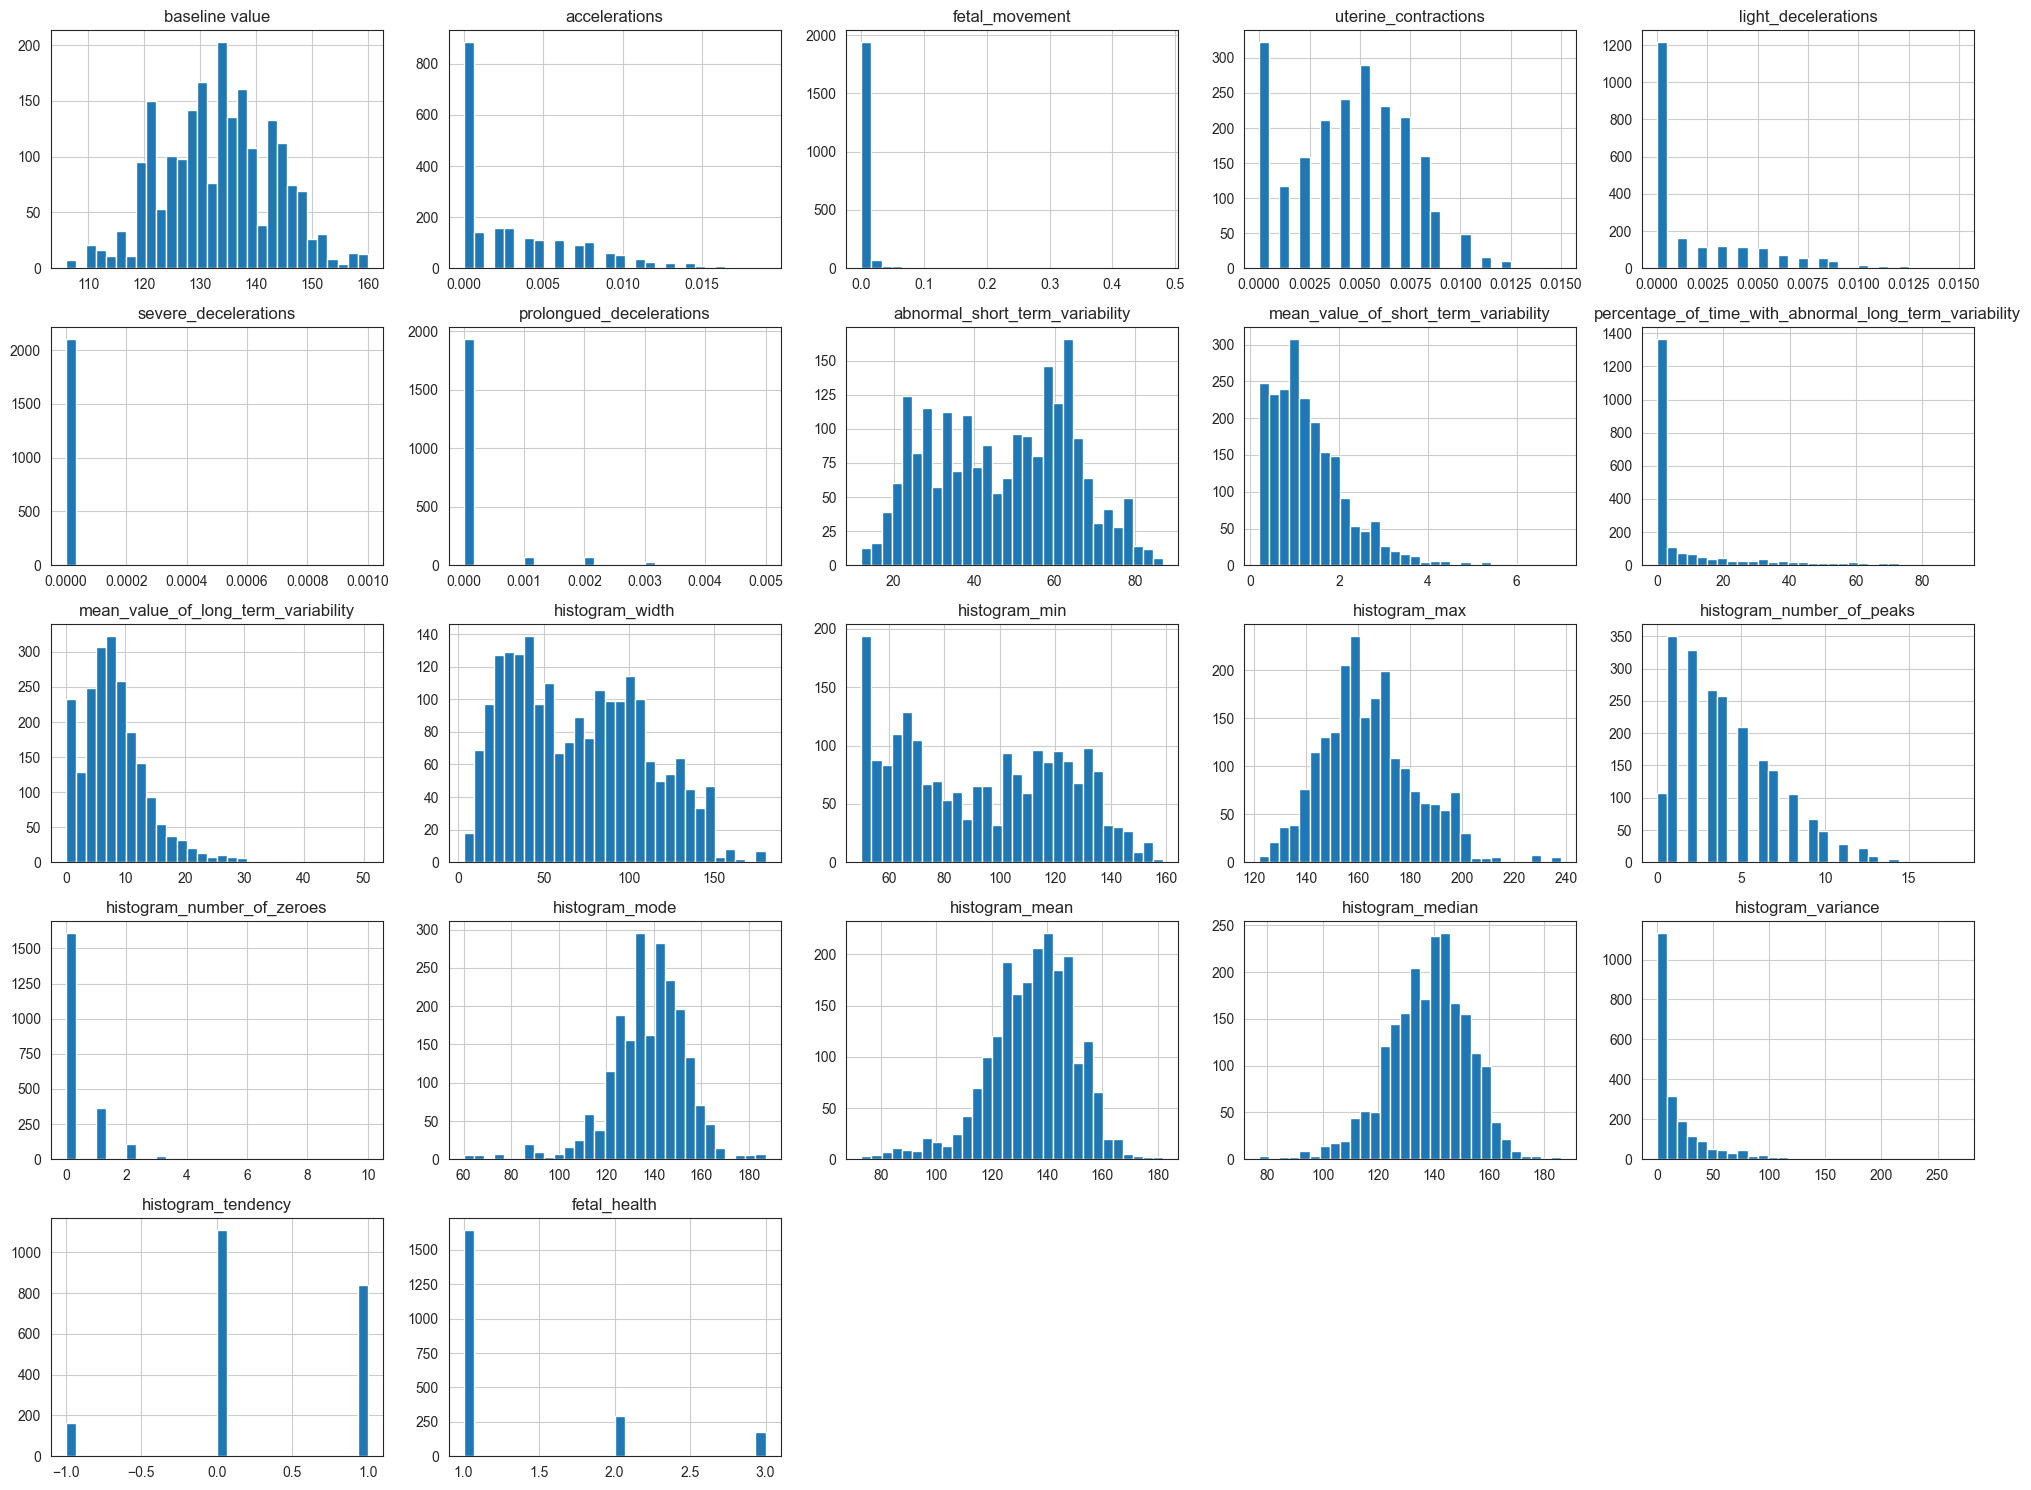

In [75]:
df.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

# Boxplot of One Feature vs Target

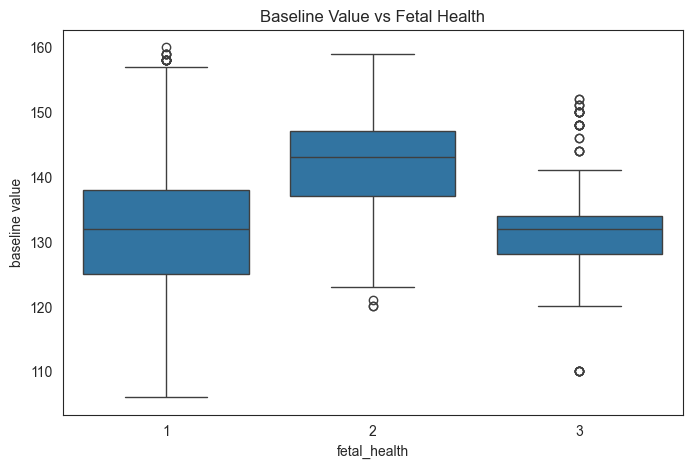

In [76]:
plt.figure(figsize=(8,5))
sns.boxplot(x="fetal_health", y="baseline value", data=df)
plt.title("Baseline Value vs Fetal Health")
plt.show()

# Boxplots of All Features vs Target

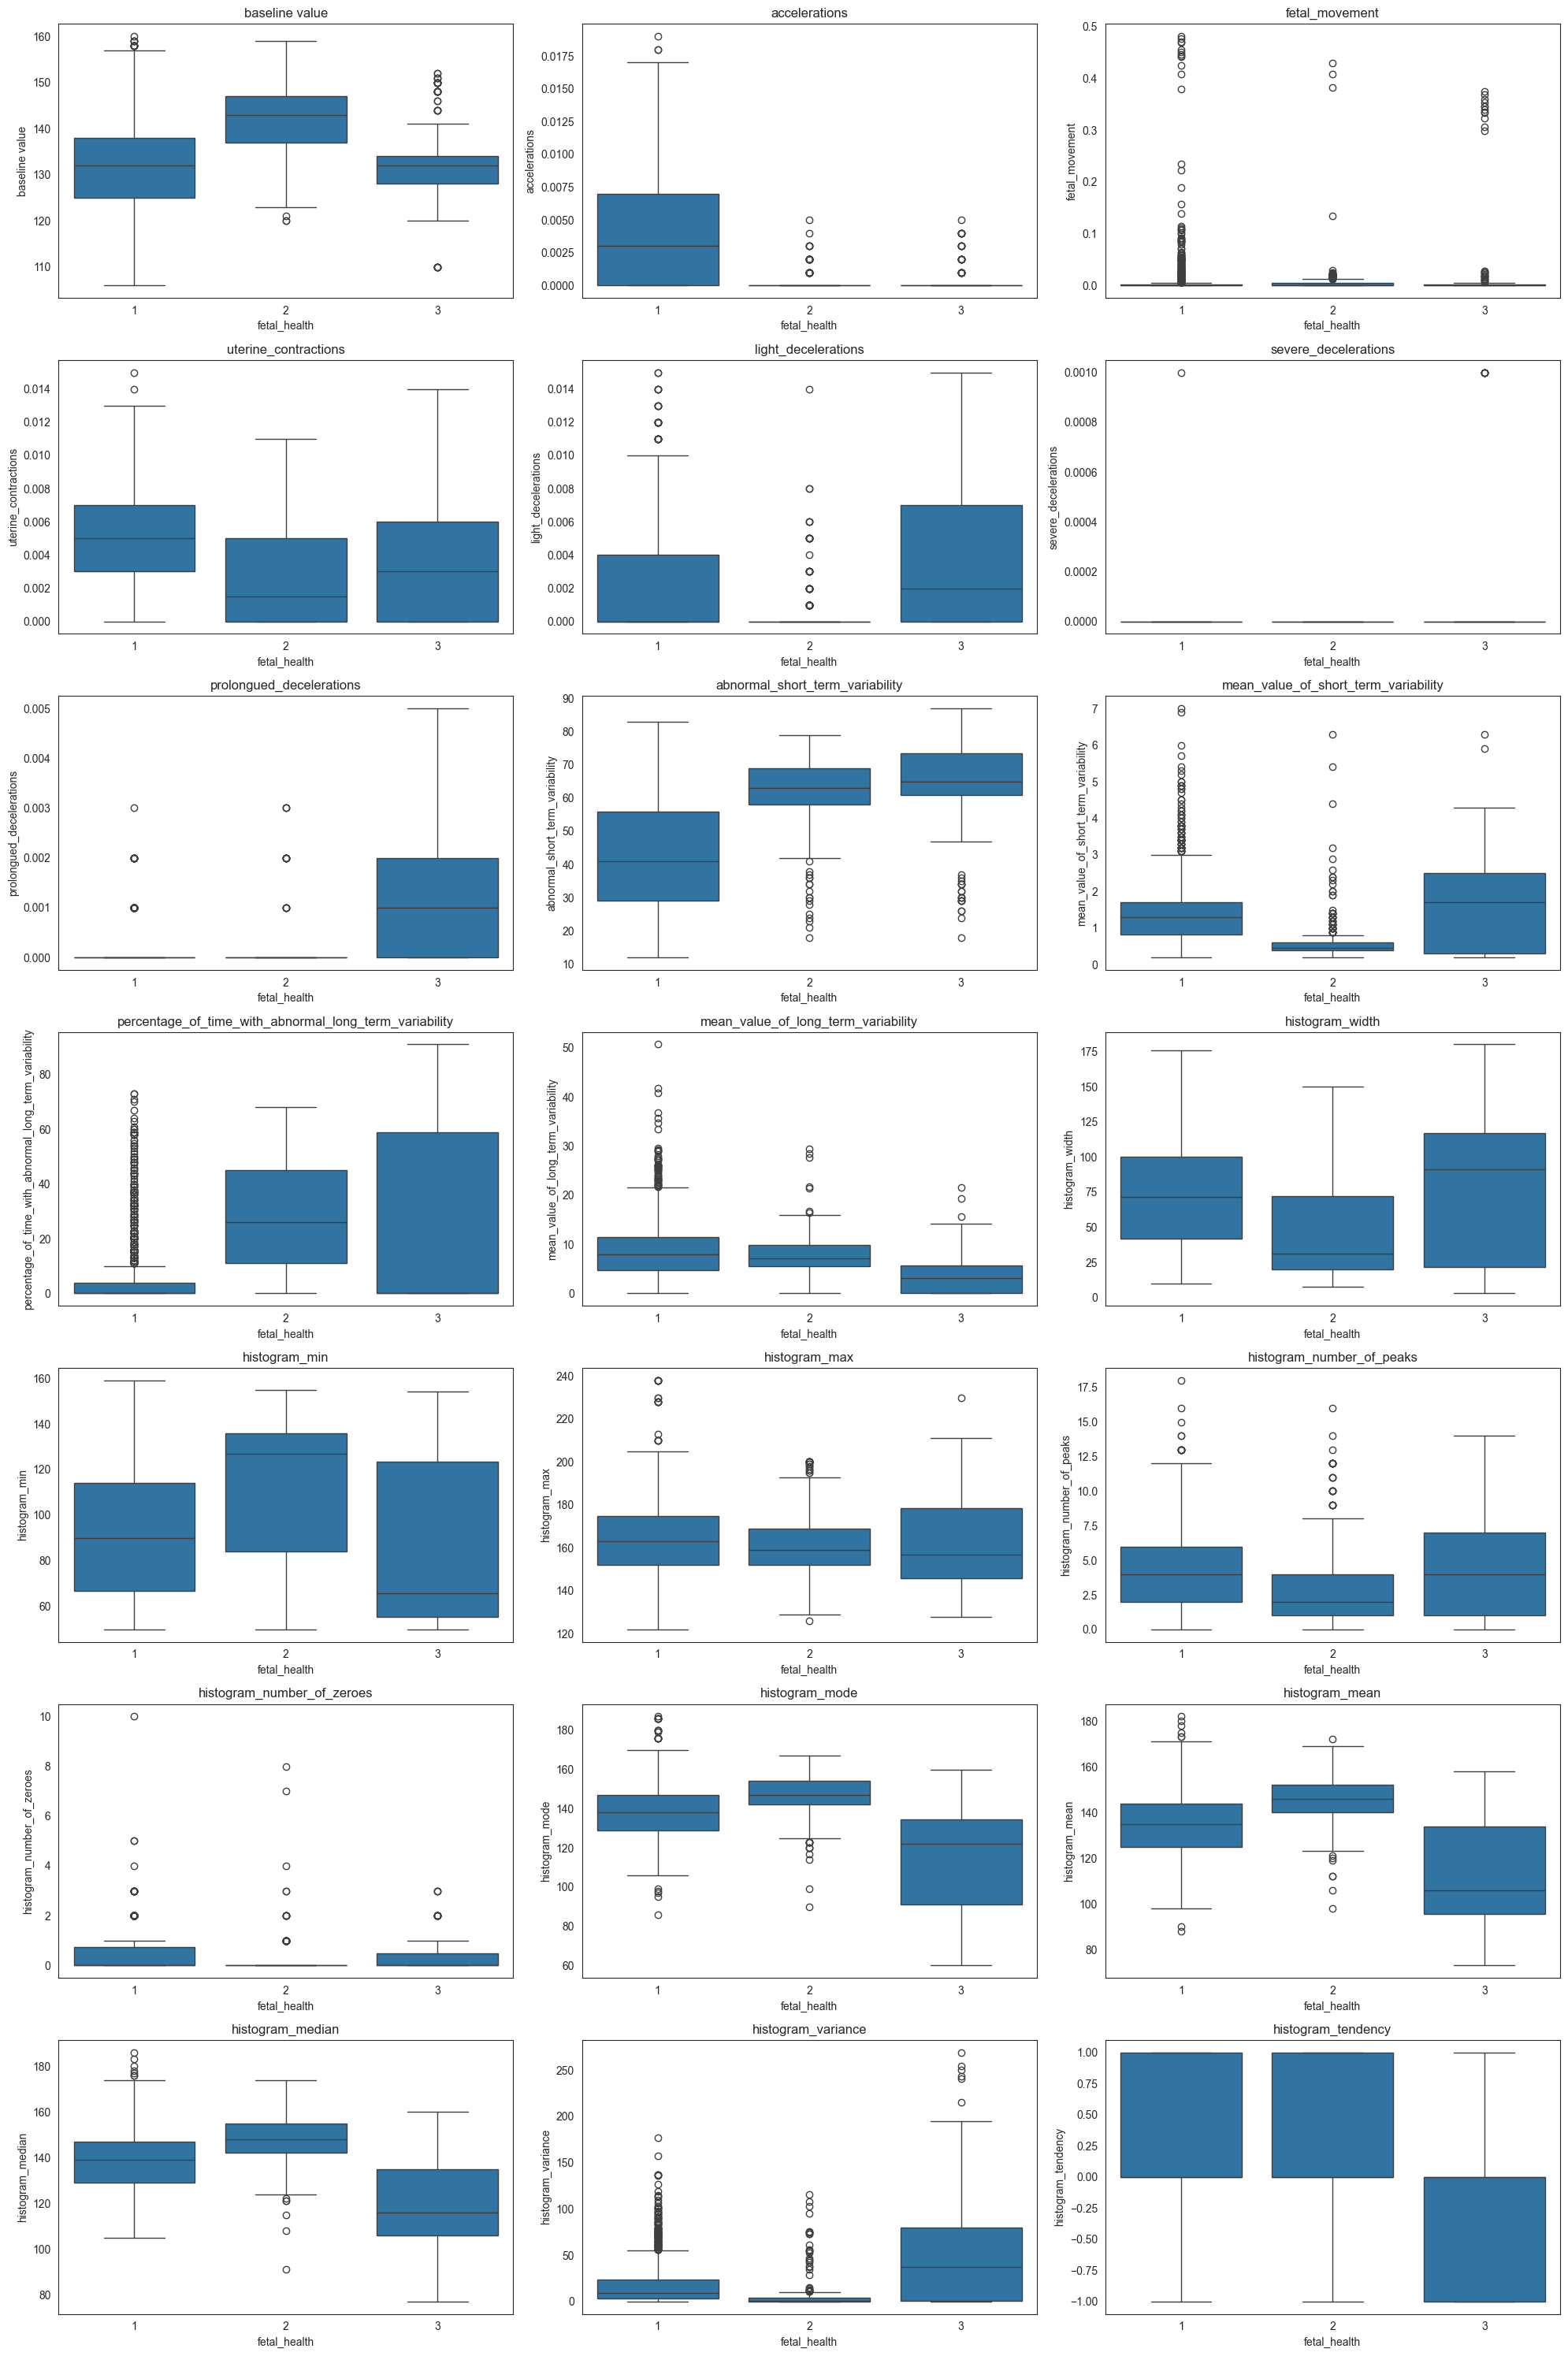

In [77]:
features = df.columns.drop("fetal_health")

plt.figure(figsize=(20, 30))

for i, col in enumerate(features):
    plt.subplot(7, 3, i+1)
    sns.boxplot(x="fetal_health", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

## Identify highly correlated feature pairs

### Why this cell is used
- This cell finds pairs of features whose absolute correlation is above a chosen threshold.
- Highly correlated feature pairs often represent redundant information.
- This helps justify dropping one feature from each highly correlated pair during feature reduction.

In [78]:
corr = df.drop(columns=["fetal_health"]).corr()
threshold = 0.85

pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            pairs.append((cols[i], cols[j], val))

high_corr_pairs = pd.DataFrame(pairs, columns=["feature_1","feature_2","corr"]).sort_values("corr", ascending=False)
display(high_corr_pairs.head(25))

,feature_1,feature_2,corr
3,histogram_mean,histogram_median,0.948077
2,histogram_mode,histogram_median,0.933166
1,histogram_mode,histogram_mean,0.893083
0,histogram_width,histogram_min,-0.899054


# Correlation Heatmap

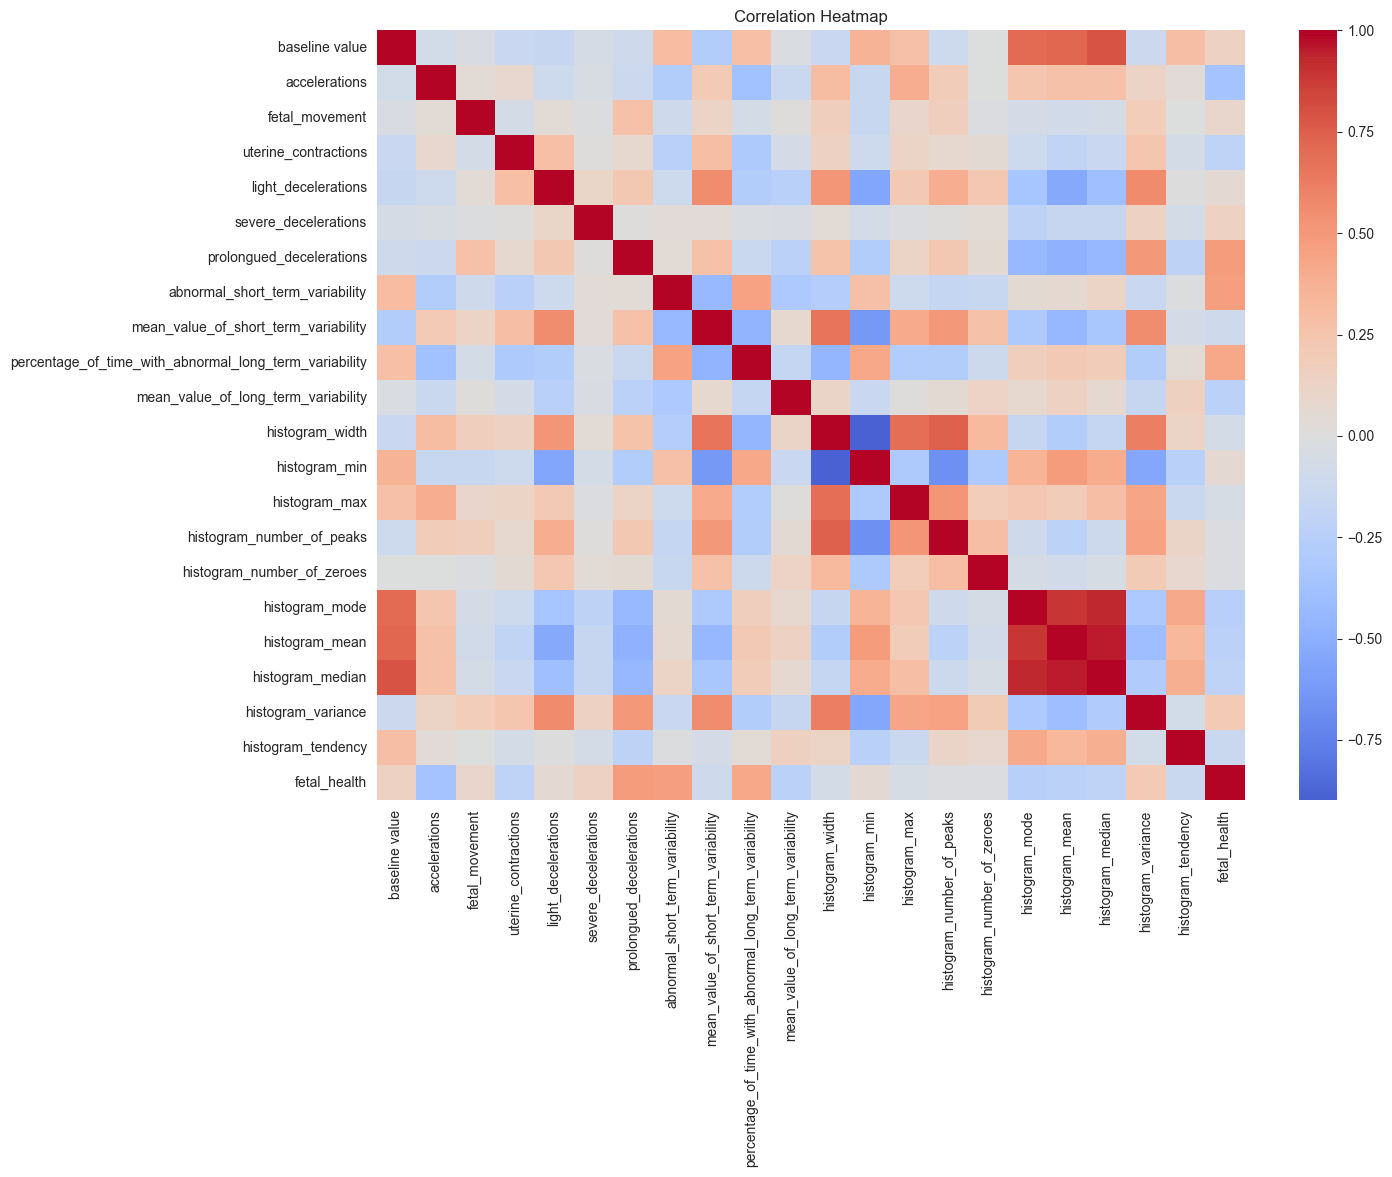

In [79]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Correlation with Target

In [80]:
df.corr()["fetal_health"].sort_values(ascending=False)

fetal_health                                              1.000000
prolongued_decelerations                                  0.486752
abnormal_short_term_variability                           0.469671
percentage_of_time_with_abnormal_long_term_variability    0.421634
histogram_variance                                        0.208171
baseline value                                            0.146077
severe_decelerations                                      0.132408
fetal_movement                                            0.088057
histogram_min                                             0.063529
light_decelerations                                       0.059651
histogram_number_of_zeroes                               -0.016376
histogram_number_of_peaks                                -0.022856
histogram_max                                            -0.046480
histogram_width                                          -0.069529
mean_value_of_short_term_variability                     -0.10

# Create feature matrix and target vector

In [81]:
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

# Split Data Before Scaling

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale the features with RobustScaler

### Why this cell is used
- This cell scales the features using RobustScaler.
- RobustScaler uses the median and IQR, so it is less affected by skewness and outliers than StandardScaler.
- This is a good choice for your CTG dataset because many variables are heavily skewed.

In [83]:
scaler = RobustScaler()

# Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check shapes
X_train_scaled.shape, X_test_scaled.shape

((1690, 21), (423, 21))

# Class Distribution in the Training Set

In [84]:
# Class counts in training set
y_train.value_counts()

# Percentages
y_train.value_counts(normalize=True) * 100

fetal_health
1    77.869822
2    13.846154
3     8.284024
Name: proportion, dtype: float64

## Class distribution

### Why this cell is used
- This cell counts the number of observations in each target class.
- Class distribution is important because imbalanced classes can affect model training and evaluation.
- In this dataset, the Normal class is larger than the Suspect and Pathological classes.

In [85]:
y_train.value_counts()

fetal_health
1    1316
2     234
3     140
Name: count, dtype: int64

# Apply SMOTE to the Training Set
This is used to fix data imbalance

In [86]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

# Check new class distribution
pd.Series(y_train_resampled).value_counts()

fetal_health
1    1316
2    1316
3    1316
Name: count, dtype: int64

# Convert Resampled Data Back to DataFrame

# Feature Selection/Relevance: Kruskal-Wallis
* A Kruskal-Wallis statistical test was performed to determine whether feature distributions differed significantly across fetal health classes. 
* Features with statistically significant differences (p < 0.05) were prioritized for model training.

In [87]:
from scipy.stats import kruskal

X_cols = [c for c in df.columns if c != "fetal_health"]
rows = []
for col in X_cols:
    g1 = df[df["fetal_health"]==1][col]
    g2 = df[df["fetal_health"]==2][col]
    g3 = df[df["fetal_health"]==3][col]
    stat, p = kruskal(g1, g2, g3)
    rows.append((col, stat, p))

kruskal_rank = pd.DataFrame(rows, columns=["feature","H_stat","p_value"]).sort_values("p_value")
display(kruskal_rank.head(15))


,feature,H_stat,p_value
6,prolongued_decelerations,537.868951,1.596766e-117
7,abnormal_short_term_variability,525.447630,7.952375e-115
9,percentage_of_time_with_abnormal_long_term_var...,488.674525,7.685554e-107
1,accelerations,446.130546,1.330402e-97
8,mean_value_of_short_term_variability,377.096891,1.301519e-82
17,histogram_mean,302.150750,2.447926e-66
18,histogram_median,293.164552,2.188398e-64
16,histogram_mode,268.334798,5.393107e-59
0,baseline value,249.358384,7.120572e-55
19,histogram_variance,225.701654,9.761319e-50


In [88]:
X_train_resampled = pd.DataFrame(
    X_train_resampled,
    columns=X.columns
)

# Feature Selection/Relevance: Mutual Information
* Mutual Information ranking was used to measure the dependency between each feature and the fetal health target variable. 
* Unlike simple correlation, Mutual Information can capture both linear and nonlinear relationships. 
* Features with higher MI scores contain more predictive information about fetal health and were therefore prioritized during feature selection.

In [89]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train_resampled, y_train_resampled, random_state=42)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores

histogram_mean                                            0.572030
mean_value_of_short_term_variability                      0.569980
histogram_median                                          0.550101
histogram_mode                                            0.520730
histogram_variance                                        0.467981
abnormal_short_term_variability                           0.462624
percentage_of_time_with_abnormal_long_term_variability    0.461742
histogram_width                                           0.458344
mean_value_of_long_term_variability                       0.447542
baseline value                                            0.421205
histogram_min                                             0.410271
histogram_max                                             0.366849
uterine_contractions                                      0.327210
histogram_number_of_peaks                                 0.306074
accelerations                                             0.28

# Select Top 6 Features

In [90]:
# 1) Top features from MI and Kruskal tests
top_mi = list(mi_scores.head(15).index)
top_kw = list(kruskal_rank.head(15)["feature"])

# union of strong candidates
candidates = list(dict.fromkeys(top_mi + top_kw))
candidates[:20], len(candidates)

(['histogram_mean',
  'mean_value_of_short_term_variability',
  'histogram_median',
  'histogram_mode',
  'histogram_variance',
  'abnormal_short_term_variability',
  'percentage_of_time_with_abnormal_long_term_variability',
  'histogram_width',
  'mean_value_of_long_term_variability',
  'baseline value',
  'histogram_min',
  'histogram_max',
  'uterine_contractions',
  'histogram_number_of_peaks',
  'accelerations',
  'prolongued_decelerations',
  'light_decelerations'],
 17)

## Identify highly correlated feature pairs

### Why this cell is used
- This cell finds pairs of features whose absolute correlation is above a chosen threshold.
- Highly correlated feature pairs often represent redundant information.
- This helps justify dropping one feature from each highly correlated pair during feature reduction.

In [91]:
corr = df.drop(columns=["fetal_health"]).corr()
threshold = 0.85

pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            pairs.append((cols[i], cols[j], val))

high_corr_pairs = pd.DataFrame(pairs, columns=["feature_1","feature_2","corr"]).sort_values("corr", ascending=False)
display(high_corr_pairs.head(25))

,feature_1,feature_2,corr
3,histogram_mean,histogram_median,0.948077
2,histogram_mode,histogram_median,0.933166
1,histogram_mode,histogram_mean,0.893083
0,histogram_width,histogram_min,-0.899054


# Final feature selection
* Researching online CTG most important features read by doctors are:
    * Baseline
    * Variability
    * Acceleration
    * Decelaration
* Final selection was gotten from Mutual information + Kruskal tests + removing redundat information (Dropping high correlated feature pairs) + Focusing on features of CTG that are important to doctors.

In [92]:
final_features = [
    "abnormal_short_term_variability",
    "percentage_of_time_with_abnormal_long_term_variability",
    "mean_value_of_short_term_variability",
    "prolongued_decelerations",
    "accelerations",
    "baseline value",
    "histogram_variance",   
]
final_features

['abnormal_short_term_variability',
 'percentage_of_time_with_abnormal_long_term_variability',
 'mean_value_of_short_term_variability',
 'prolongued_decelerations',
 'accelerations',
 'baseline value',
 'histogram_variance']

In [93]:
# 3) Builld training matrices for the final feature set
X_train_selected = X_train_resampled[final_features]
X_test_selected = pd.DataFrame(X_test_scaled, columns=X.columns)[final_features]

X_train_selected.shape, X_test_selected.shape

((3948, 7), (423, 7))

# Model 1- Logistic Regression

In [94]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_selected, y_train_resampled)

# Predict on test set
y_pred = model.predict(X_test_selected)

# Evaluate the Model

In [95]:
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.806146572104019

Classification Report:

              precision    recall  f1-score   support

           1       0.95      0.83      0.88       330
           2       0.46      0.67      0.55        58
           3       0.57      0.83      0.67        35

    accuracy                           0.81       423
   macro avg       0.66      0.78      0.70       423
weighted avg       0.85      0.81      0.82       423


Confusion Matrix:

[[273  40  17]
 [ 14  39   5]
 [  0   6  29]]


# Plot Confusion Matrix for Logistic Regression

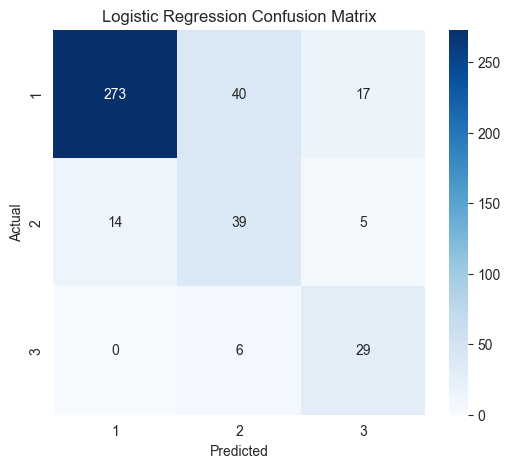

In [96]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1,2,3],
            yticklabels=[1,2,3])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Model 2- Random Forest Model

In [97]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_selected, y_train_resampled)

y_pred_rf = rf.predict(X_test_selected)

# Evaluate the Random Forest Model

In [98]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9267139479905437

Classification Report:

              precision    recall  f1-score   support

           1       0.95      0.97      0.96       330
           2       0.80      0.71      0.75        58
           3       0.91      0.89      0.90        35

    accuracy                           0.93       423
   macro avg       0.89      0.85      0.87       423
weighted avg       0.92      0.93      0.92       423


Confusion Matrix:

[[320   9   1]
 [ 15  41   2]
 [  3   1  31]]


# Cross-validate the Random
- This cell performs cross-validation on the Random Forest model.
- Cross-validation checks whether the model performs consistently across different splits of the training data.
- It helps demonstrate that the model is stable and not just lucky on one split.

In [99]:
rf_cv = RandomForestClassifier(random_state=42)

scores = cross_val_score(
    rf_cv,
    X_train_selected,
    y_train_resampled,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV accuracy:", np.mean(scores))

CV scores: [0.93417722 0.9835443  0.97594937 0.98225602 0.97972117]
Mean CV accuracy: 0.9711296144775472


# Plot ROC Curves for the Random Forest

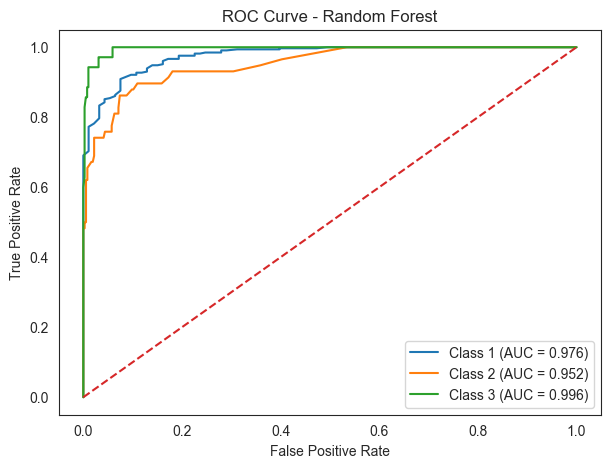

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels for multiclass ROC
classes = [1, 2, 3]
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities from Random Forest
y_score = rf.predict_proba(X_test_selected)

plt.figure(figsize=(7,5))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {c} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# Generate ROC Curves for Logistic Regression

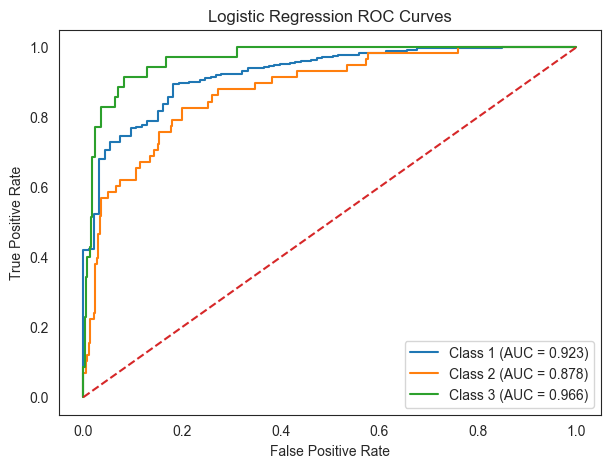

In [101]:
y_score_log = model.predict_proba(X_test_selected)

plt.figure(figsize=(7,5))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_log[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {c} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.title("Logistic Regression ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Feature Importance plot for Random Forest Model

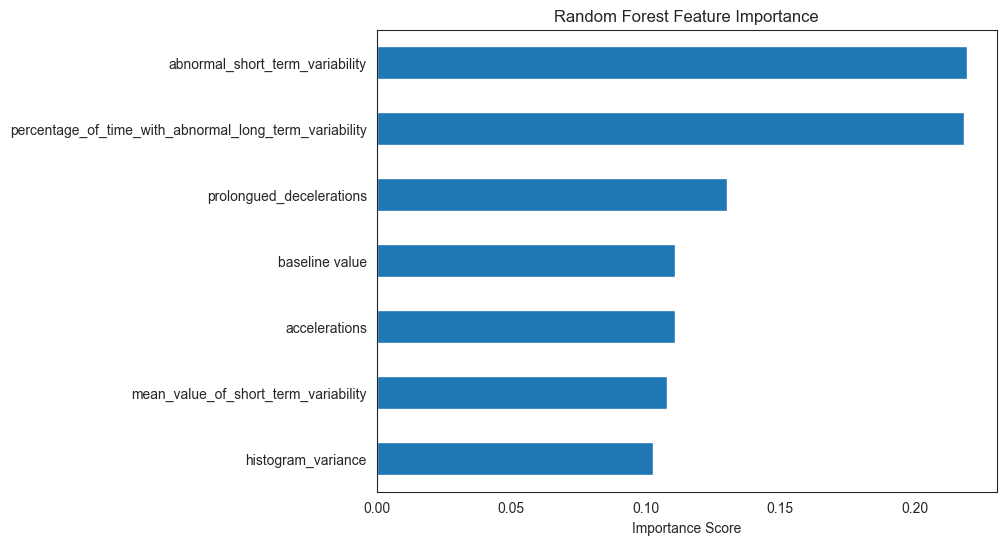

In [102]:
# create importance series
rf_importance = pd.Series(rf.feature_importances_, index=final_features)
rf_importance = rf_importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))
rf_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# Model 3- K-Nearest Neighbors Model

In [103]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_selected, y_train_resampled)

y_pred_knn = knn.predict(X_test_selected)

# Evaluate the KNN Model

In [104]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.8557919621749409

Classification Report:

              precision    recall  f1-score   support

           1       0.99      0.85      0.91       330
           2       0.60      0.86      0.70        58
           3       0.59      0.94      0.73        35

    accuracy                           0.86       423
   macro avg       0.72      0.88      0.78       423
weighted avg       0.90      0.86      0.87       423


Confusion Matrix:

[[279  32  19]
 [  4  50   4]
 [  0   2  33]]


# Confusion Matrix

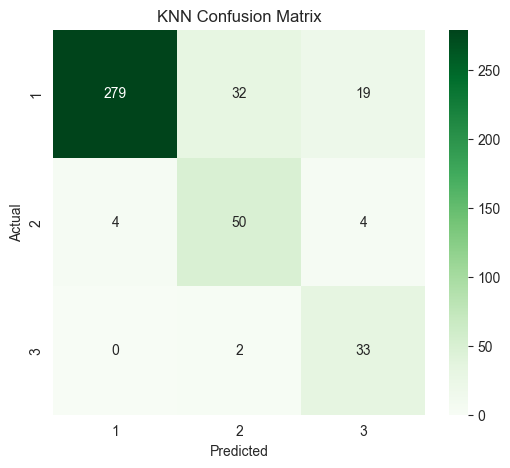

In [105]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens",
            xticklabels=[1,2,3],
            yticklabels=[1,2,3])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

# Generate ROC Curves for KNN

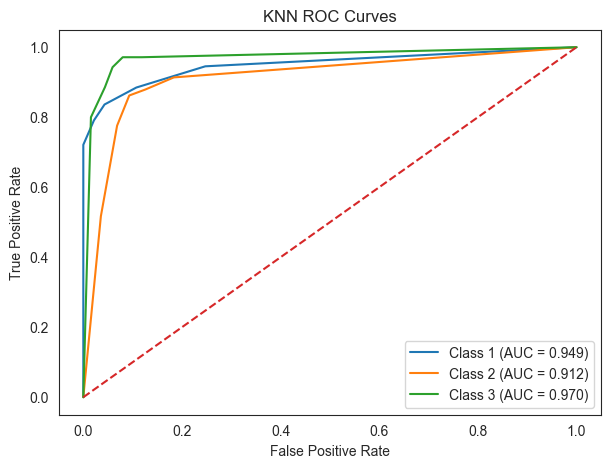

In [106]:
y_score_knn = knn.predict_proba(X_test_selected)

plt.figure(figsize=(7,5))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_knn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {c} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.title("KNN ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 4th Model- SVM

In [107]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm.fit(X_train_selected, y_train_resampled)

y_pred_svm = svm.predict(X_test_selected)

# Evaluate SVM Model

In [108]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8250591016548463

Classification Report:

              precision    recall  f1-score   support

           1       0.97      0.82      0.89       330
           2       0.51      0.79      0.62        58
           3       0.60      0.94      0.73        35

    accuracy                           0.83       423
   macro avg       0.69      0.85      0.75       423
weighted avg       0.88      0.83      0.84       423


Confusion Matrix:

[[270  42  18]
 [  8  46   4]
 [  0   2  33]]


# Generate ROC Curves for SVC

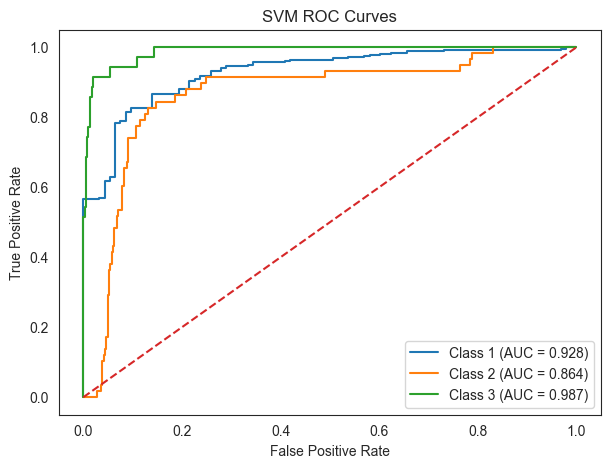

In [109]:
# SVM ROC
y_score_svm = svm.decision_function(X_test_selected)

plt.figure(figsize=(7,5))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {c} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.title("SVM ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Model Accuracy Comparison Plot

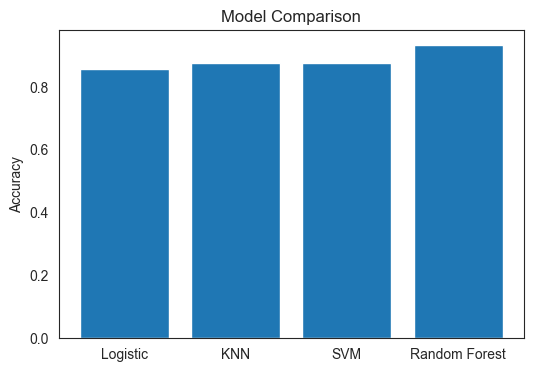

In [110]:
models = ["Logistic", "KNN", "SVM", "Random Forest"]
scores = [
    0.858,
    0.875,
    0.877,
    0.934
]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

# Save the Final Model

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

rf_final.fit(X_train_selected, y_train_resampled)


check_is_fitted(rf_final)

print("Model is fitted successfully.")

Model is fitted successfully.


# Create the deployment bundle for your Random Forest app

In [114]:
import joblib

bundle = {
    "model": rf_final,          
    "scaler": scaler,
    "top_features": list(final_features),
    "all_features": list(X.columns)
}

joblib.dump(bundle, "fetal_health_rf_bundle.pkl")


['fetal_health_rf_bundle.pkl']

pip install streamlit
python -m streamlit run app.py